In [1]:
# import dataset
from tensorflow.keras.datasets import mnist

In [2]:
# load datset
 (x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


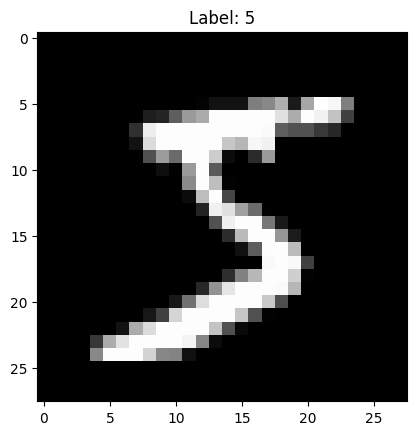

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

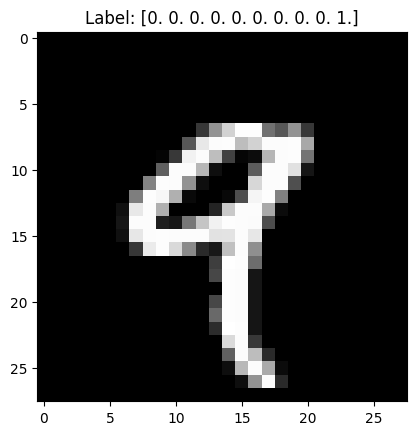

In [29]:
import matplotlib.pyplot as plt
plt.imshow(x_train[4].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[4]}")
plt.show()

In [5]:
# Preprocess (flatten + normalize + one-hot encode
from tensorflow.keras.utils import to_categorical

In [6]:
#Flatten 28*28 images into 784 features
x_train = x_train.reshape((60000, 28*28)).astype('float32')/255
x_test = x_test.reshape((10000, 28*28)).astype('float32')/255

In [7]:
# One-Hot Encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [8]:
# import necessary libraries
from tensorflow.keras.models import  Sequential
from tensorflow.keras.layers import Dense


In [13]:
# Build ANN (Sequential + Dense layers)
model = Sequential()
model.add(Dense(128, activation = 'relu', input_shape = (784, )))

model.add(Dense(64, activation = 'relu'))
model.add(Dense(10, activation='softmax'))

In [14]:
# Compile (optimizer + loss + metrics)
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [16]:
# Train (fit with epochs & batch size

trained_model= model.fit(x_train, y_train, epochs=5, batch_size = 32, validation_split = 0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8662 - loss: 0.4542 - val_accuracy: 0.9667 - val_loss: 0.1109
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9652 - loss: 0.1163 - val_accuracy: 0.9745 - val_loss: 0.0887
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9776 - loss: 0.0740 - val_accuracy: 0.9780 - val_loss: 0.0813
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9832 - loss: 0.0539 - val_accuracy: 0.9773 - val_loss: 0.0813
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9861 - loss: 0.0434 - val_accuracy: 0.9800 - val_loss: 0.0841


In [19]:
# Evaluate (accuracy on test set)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0868
Test Accuracy: 0.9772999882698059


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


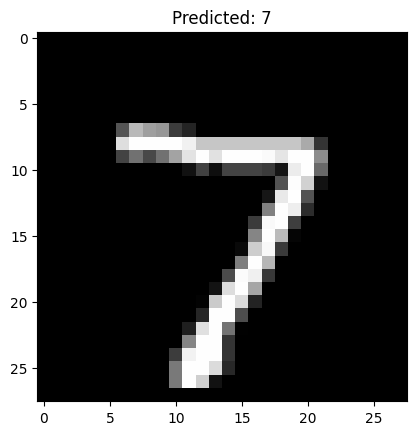

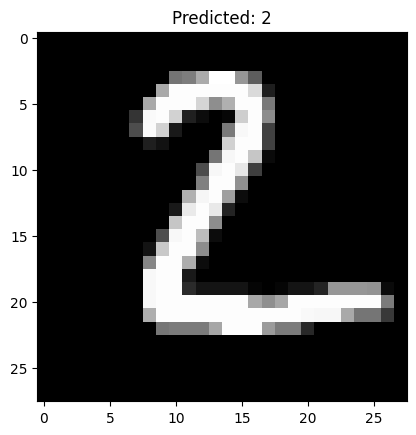

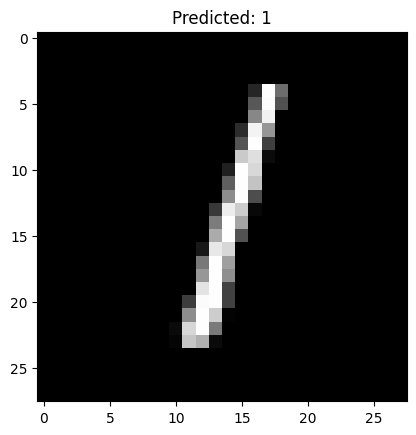

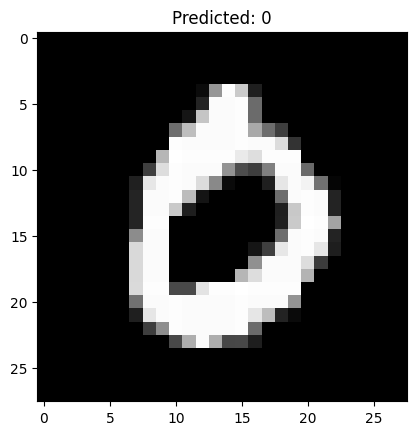

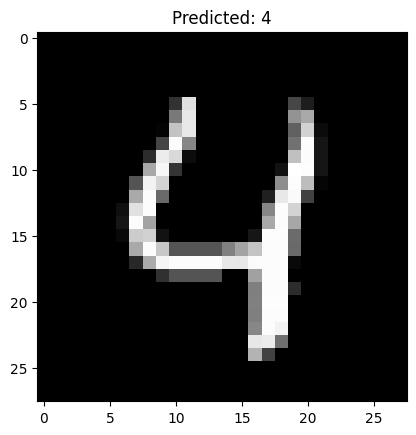

In [22]:
# Predict
import numpy as np
predictions = model.predict(x_test[:5])

for i in range(5):
  plt.imshow(x_test[i].reshape(28,28),cmap='grey')
  plt.title(f"Predicted: {np.argmax(predictions[i])}")
  plt.show()